# Analyzing synthetic weather data 
**Objective**: 

- Summarize weather patterns by city and season to support high-level operational planning.
- Identify time periods or cities with extreme or volatile weather conditions that may affect public services or infrastructure readiness.
- Detect trends and shifts in climate patterns using rolling averages and seasonal decomposition.
- Explore relationships between temperature, humidity, wind, and precipitation to uncover potential drivers of extreme conditions.
- Present insights visually and narratively in a way that is clear, accessible, and decision-focused.

**Dataset(s)**: 

Found on Kaggle ([source](https://www.kaggle.com/datasets/prasad22/weather-data)), this dataset contains 1 million records in a 99 MB `CSV` file. 

The data recorded is location, date and time, temperature, humidity, precipitation, and wind speed.

**Tools Used**:

Python
- pandas
- matplotlib
- numpy
- seaborn

## 1. Introduction

This project explores a fictional dataset containing weather measurements across multiple cities, including temperature, humidity, precipitation, wind speed, and timestamped records. The goal is to simulate a real-world data analysis workflow that supports actionable insights for stakeholders, such as city planners, business operators, or logistics managers.

Through this project, I demonstrate core competencies in exploratory data analysis (EDA), time-series analysis, data visualization, and stakeholder-style reporting. Emphasis is placed on identifying temporal trends, geographic differences, extreme events, and meaningful correlations between weather variables.

In [28]:
# Import packages and variables
import pandas as pd
import numpy as np
from numpy import sign
import matplotlib.pyplot as plt
import seaborn as sns
import re
from os.path import join
from IPython.display import HTML
from utilities.config import raw_data_path, processed_data_path, data_dir, weather_vars, products_dir, images_dir

# Visualization settings
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [29]:
print(weather_vars)

['temperature', 'humidity', 'precipitation', 'windspeed']


## 2. Data preview

In [30]:
# Load data
df = pd.read_csv(raw_data_path, parse_dates=['Date_Time'])

# Preview data
df.head()

,Location,Date_Time,Temperature_C,Humidity_pct,Precipitation_mm,Wind_Speed_kmh
0,San Diego,2024-01-14 21:12:46,10.683001,41.195754,4.020119,8.233540
1,San Diego,2024-05-17 15:22:10,8.734140,58.319107,9.111623,27.715161
2,San Diego,2024-05-11 09:30:59,11.632436,38.820175,4.607511,28.732951
3,Philadelphia,2024-02-26 17:32:39,-8.628976,54.074474,3.183720,26.367303
4,San Antonio,2024-04-29 13:23:51,39.808213,72.899908,9.598282,29.898622


In [31]:
# Structure and summary
df.info()
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 6 columns):
 #   Column            Non-Null Count    Dtype         
---  ------            --------------    -----         
 0   Location          1000000 non-null  object        
 1   Date_Time         1000000 non-null  datetime64[ns]
 2   Temperature_C     1000000 non-null  float64       
 3   Humidity_pct      1000000 non-null  float64       
 4   Precipitation_mm  1000000 non-null  float64       
 5   Wind_Speed_kmh    1000000 non-null  float64       
dtypes: datetime64[ns](1), float64(4), object(1)
memory usage: 45.8+ MB


,Location,Date_Time,Temperature_C,Humidity_pct,Precipitation_mm,Wind_Speed_kmh
count,1000000,1000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
unique,10,NaN,NaN,NaN,NaN,NaN
top,Phoenix,NaN,NaN,NaN,NaN,NaN
freq,100209,NaN,NaN,NaN,NaN,NaN
mean,NaN,2024-03-10 10:40:58.896321792,14.779705,60.021830,5.109639,14.997598
min,NaN,2024-01-01 00:00:06,-19.969311,30.000009,0.000009,0.000051
25%,NaN,2024-02-04 16:28:23.750000128,2.269631,45.008500,2.580694,7.490101
50%,NaN,2024-03-10 11:43:28,14.778002,60.018708,5.109917,14.993777
75%,NaN,2024-04-14 03:51:32.500000,27.270489,75.043818,7.613750,22.514110
max,NaN,2024-05-18 19:44:10,39.999801,89.999977,14.971583,29.999973


### Summary

There does not seem to be any obvious issues with the data.

The data types make sense.

None of the records are missing any column values and the ranges of values found in each of the numeric columns appear to have no unusual or impossible values.

One thing that is interesting to note is that the mean and median for each numeric column is nearly identical. In a real-world situation, I think that would require closer scrutiny, as perfectly symmetrical weather data seems unlikely.

## 3. Data cleaning and preparation

In [32]:
# Rename columns to ease use
names = {
    'Location': 'location',
    'Date_Time': 'datetime',
    'Temperature_C': 'temperature',
    'Humidity_pct': 'humidity',
    'Precipitation_mm': 'precipitation',
    'Wind_Speed_kmh': 'windspeed'
}
df.rename(inplace=True, columns=names)
print(df.dtypes)


location                 object
datetime         datetime64[ns]
temperature             float64
humidity                float64
precipitation           float64
windspeed               float64
dtype: object


In [33]:
# Check for duplicate records
duplicates = df[df.duplicated(subset=['location', 'datetime'], keep=False)].sort_values(['location', 'datetime'])
duplicates.to_csv(join(data_dir, 'duplicates.csv')) # export to data file 'duplicates.csv'
display(duplicates.head(10))
print('Number of duplicate records: ', duplicates.shape[0])
print(duplicates.location.value_counts())

,location,datetime,temperature,humidity,precipitation,windspeed
138002,Chicago,2024-01-01 05:42:05,33.885939,51.196421,7.223224,23.560251
515729,Chicago,2024-01-01 05:42:05,-5.311788,79.611929,6.933497,2.759744
862891,Chicago,2024-01-01 06:56:45,0.861692,88.027134,3.701042,13.913699
875558,Chicago,2024-01-01 06:56:45,6.179934,86.207245,7.995065,16.488742
121537,Chicago,2024-01-01 08:15:35,0.224201,58.737580,8.984158,17.326420
463293,Chicago,2024-01-01 08:15:35,27.933899,53.206322,1.592291,11.743219
348495,Chicago,2024-01-01 19:52:32,4.801427,82.052006,7.228739,23.794739
773493,Chicago,2024-01-01 19:52:32,37.500646,86.754098,2.484501,16.868771
84139,Chicago,2024-01-01 21:15:26,-7.321957,60.503589,3.844922,9.412107
939671,Chicago,2024-01-01 21:15:26,23.633388,35.562760,2.230606,16.925906


Number of duplicate records:  8221
location
Philadelphia    871
San Diego       867
Phoenix         861
Chicago         838
San Jose        838
Los Angeles     819
San Antonio     797
Houston         795
New York        791
Dallas          744
Name: count, dtype: int64


In [34]:
# Take the mean of each duplicated record (based on location and datetime) and replace the duplicated rows' values
dup_mean = duplicates.groupby(['location', 'datetime']).agg('mean').reset_index()
assert dup_mean.duplicated(subset=['location', 'datetime']).sum() == 0
df = df.drop_duplicates(subset=['location', 'datetime'], keep=False)
df = pd.concat([df, dup_mean], ignore_index=True)
df.to_csv(processed_data_path, index=False)
df.sort_values(by=['location', 'datetime'])

,location,datetime,temperature,humidity,precipitation,windspeed
988155,Chicago,2024-01-01 00:03:25,5.222404,46.395687,6.984159,1.219788
891406,Chicago,2024-01-01 00:07:14,-6.403267,42.400326,0.451659,0.979239
480096,Chicago,2024-01-01 00:09:36,8.227097,58.197003,9.686955,10.769515
981667,Chicago,2024-01-01 00:10:35,-2.955866,86.983992,0.783134,20.737256
571948,Chicago,2024-01-01 00:10:59,28.382266,35.755630,0.064871,3.502880
...,...,...,...,...,...,...
787718,San Jose,2024-05-18 19:35:42,15.774893,44.862293,8.859171,15.339799
751272,San Jose,2024-05-18 19:38:07,24.371882,31.567008,1.173650,21.119398
558694,San Jose,2024-05-18 19:39:48,3.458694,60.054116,6.270688,10.487452
897654,San Jose,2024-05-18 19:42:19,29.560058,64.699840,8.953942,16.487091


### Summary

- I renamed the columns to make working with the data (a little) easier.
- There are no missing values.
- The data type for each column is appropriate and optimal for analysis.
- There are 4121 duplicated rows, based on "location" and "datetime". Because this is synthetic data generated from reasonable ranges in each location for a given time of year, I replaced the duplicate records with a single record which averaged the values of the duplicates. I then sorted the final product by date and time.

## 4. Exploratory data analysis (EDA)
- Distribution of variables
- Relationships between key features
- Business questions explored

### Distribution visualizations

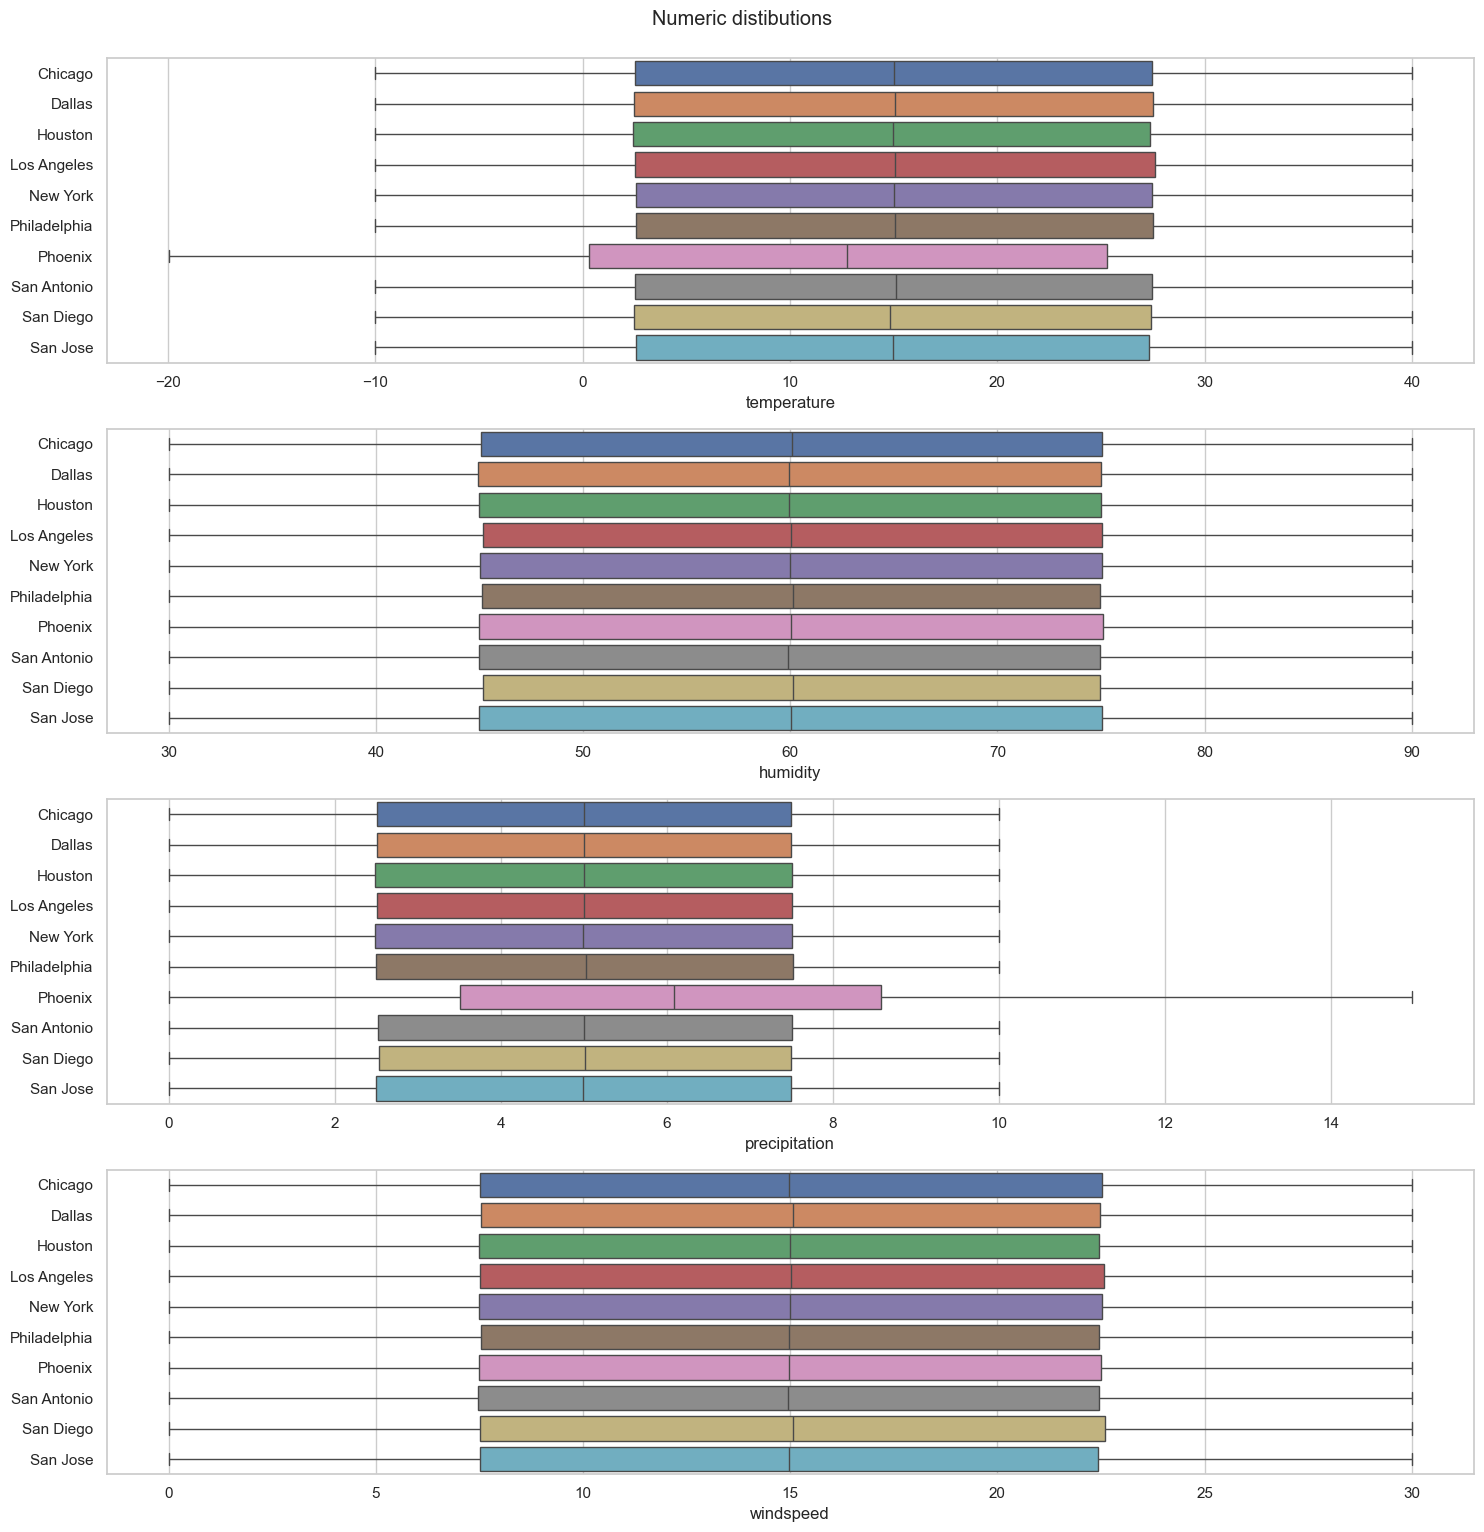

In [35]:
# Distribution of weather variables
location_order = sorted([x for x in df.location.unique()])
fig, axes = plt.subplots(len(weather_vars), 1, figsize=(15,15))
la = zip(weather_vars, axes)
target_dir = join(images_dir, 'distributions')
for l, a in la:
    sns.boxplot(df, x=l, y='location', hue='location', order=location_order, hue_order=location_order, ax=a)
    a.set_ylabel('')
plt.tight_layout()
fig.suptitle('Numeric distibutions', y=1.02)
fig.savefig(join(target_dir, 'numeric_distibutions_boxplot.png'))

Note:
These values seem pretty similar for cities that exist in very different climes (e.g. San Diego, CA and Chicago, IL).

Also, Phoenix has some odd distibutions for these variables, relative to other locations.

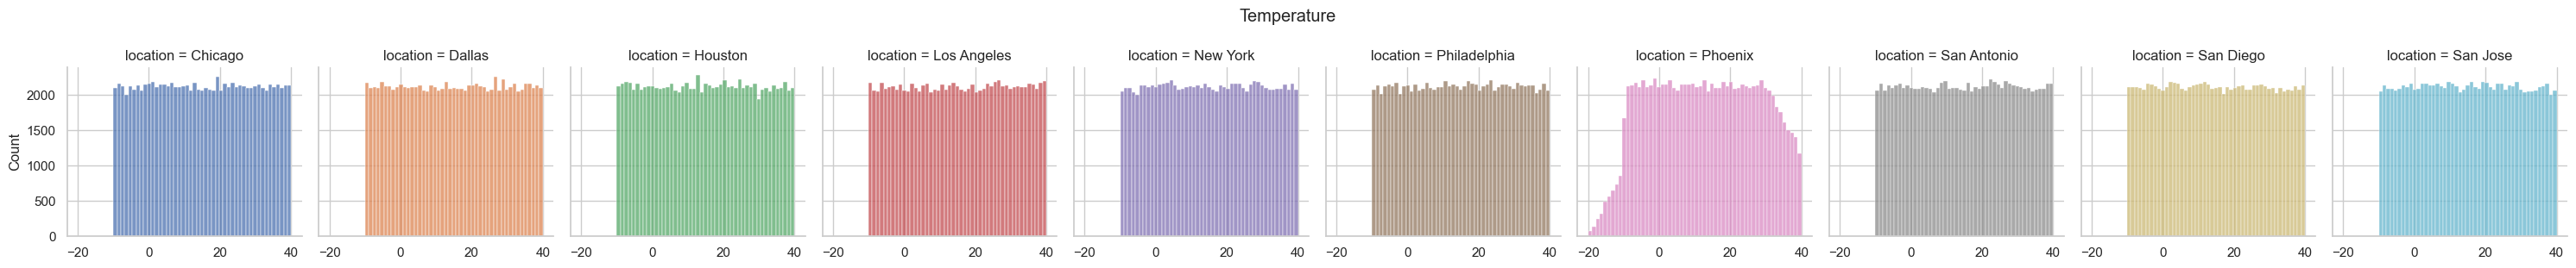

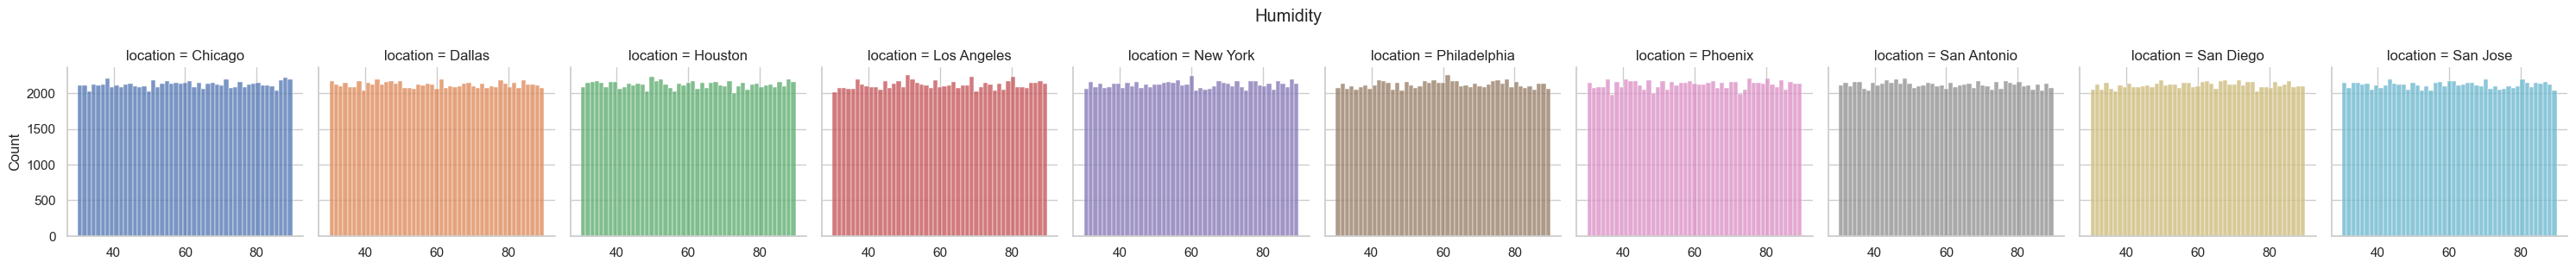

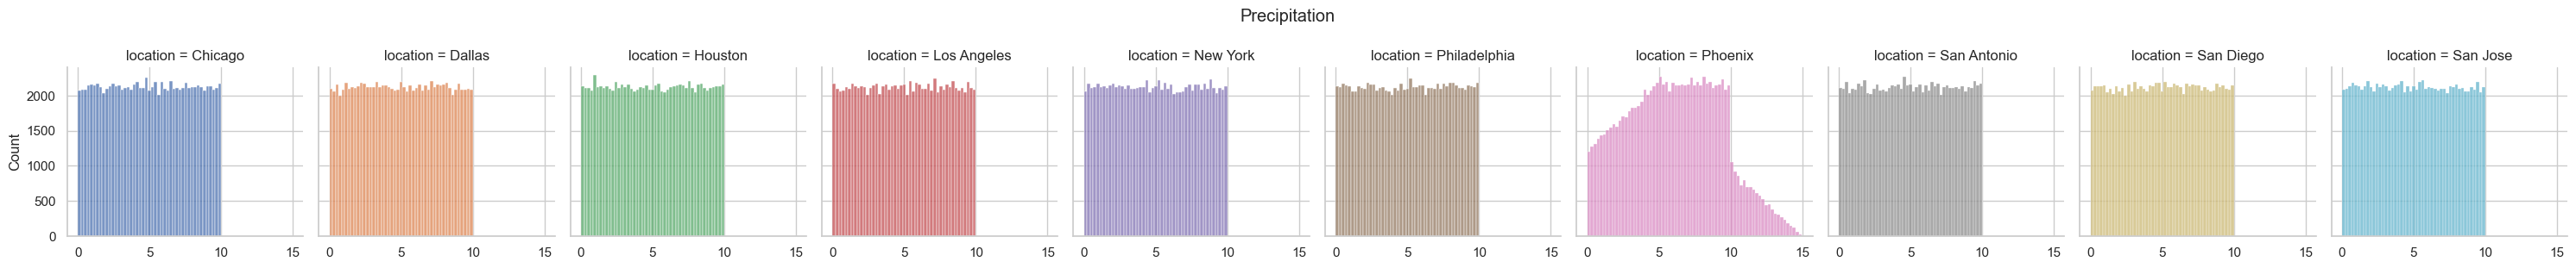

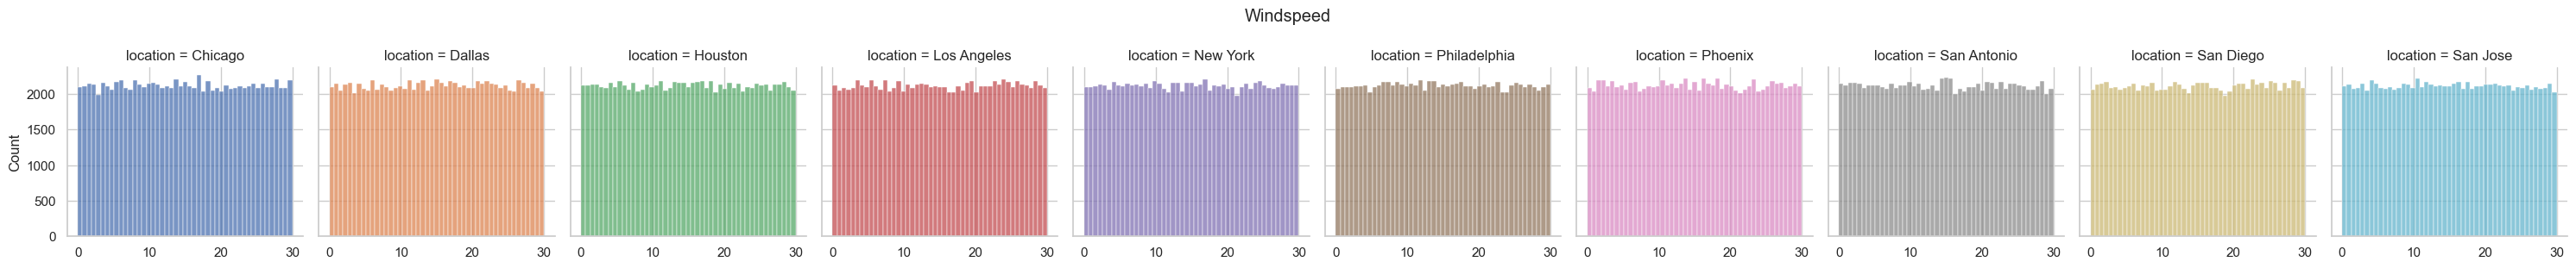

In [36]:
# Examine the distribution shape of all locations' numeric data
# TODO reorient FactGRid to have 'location' as rows and variable as columns
for c in weather_vars:
    g = sns.FacetGrid(df, col='location', hue='location', col_order=location_order, hue_order=location_order)
    g.map(sns.histplot, c)
    g.figure.suptitle(c.capitalize(), y=1.1)
    g.set_xlabels('')
    plt.savefig(join(target_dir, f'{c}_distribution.png'), bbox_inches='tight')
    plt.show()

Most "locations" have a similar uniform distribution for the numeric variables.
Phoenix is the odd one out. It has many temperature values below -10 degrees Celsius, many precipitation values above 10 mm while possessing fewer values below 5 mm precipitation than other locations.

### Averages by location

In [37]:
# Average for weather variables by location
display(df.groupby('location').agg('mean')[weather_vars])


,temperature,humidity,precipitation,windspeed
location,,,,
Chicago,15.012022,60.083549,5.002662,14.996880
Dallas,15.006249,59.961771,4.998021,15.021181
Houston,14.943023,59.967978,4.997673,14.988226
Los Angeles,15.083142,60.077038,5.003857,15.036744
New York,15.014615,60.041484,4.992532,14.990003
Philadelphia,15.034143,60.040504,5.008494,14.992811
Phoenix,12.792731,60.048100,6.086957,14.984408
San Antonio,15.028135,59.928705,5.008214,14.956428
San Diego,14.931435,60.070727,5.007100,15.037212


In [38]:
# Maxes and mins for weather variables
print('Maximums:')
display(df.groupby('location').agg('max')[weather_vars])
print('Minimums:')
display(df.groupby('location').agg('min')[weather_vars])

Maximums:


,temperature,humidity,precipitation,windspeed
location,,,,
Chicago,39.998561,89.998857,9.999889,29.999889
Dallas,39.998804,89.999929,9.999968,29.999971
Houston,39.998913,89.999082,9.999921,29.999947
Los Angeles,39.999592,89.998014,9.999522,29.999757
New York,39.999801,89.999880,9.999992,29.999681
Philadelphia,39.999642,89.999332,9.999944,29.999973
Phoenix,39.998889,89.999666,14.971583,29.999392
San Antonio,39.998343,89.999637,9.999734,29.999800
San Diego,39.999692,89.998941,9.999716,29.999920


Minimums:


,temperature,humidity,precipitation,windspeed
location,,,,
Chicago,-9.999959,30.001637,0.000118,0.000171
Dallas,-9.999588,30.000572,0.000185,0.000342
Houston,-9.999874,30.000734,0.000010,0.000119
Los Angeles,-9.999913,30.000223,0.000153,0.000173
New York,-9.999870,30.000231,0.000331,0.000199
Philadelphia,-9.999282,30.000009,0.000454,0.000272
Phoenix,-19.969311,30.002950,0.000032,0.000090
San Antonio,-9.999964,30.000028,0.000149,0.000573
San Diego,-9.999986,30.001341,0.000089,0.000614


In [39]:
# Average by season
first_date = df.datetime.min()
last_date = df.datetime.max()
spring_start = pd.to_datetime('2024-03-20')
winter_end = spring_start - pd.Timedelta(1, 'd')

print(f'Overall average by "location" for winter ({first_date.date()} through {winter_end.date()}):')
df_winter = df.loc[df.datetime.between(first_date, winter_end)]
display(df_winter.groupby('location').agg('mean')[weather_vars])

print(f'Overall average by "location" for spring ({spring_start.date()} through {last_date.date()}):')
df_spring = df.loc[df.datetime.between(spring_start, last_date)]
display(df_spring.groupby('location').agg('mean')[weather_vars])

Overall average by "location" for winter (2024-01-01 through 2024-03-19):


,temperature,humidity,precipitation,windspeed
location,,,,
Chicago,14.973418,59.989172,5.004569,14.984168
Dallas,14.916330,59.965300,4.992445,14.999354
Houston,14.941109,60.003554,4.994719,15.001508
Los Angeles,15.041370,60.068071,5.000432,15.021907
New York,14.994398,60.096840,4.994929,14.972072
Philadelphia,15.046893,60.033530,5.019946,15.014180
Phoenix,11.152697,59.998419,6.925420,15.022904
San Antonio,15.053892,59.972052,5.001410,14.955943
San Diego,14.943246,60.111047,4.999350,15.020649


Overall average by "location" for spring (2024-03-20 through 2024-05-18):


,temperature,humidity,precipitation,windspeed
location,,,,
Chicago,15.054567,60.205744,4.999727,15.020784
Dallas,15.125107,59.949459,5.006770,15.046723
Houston,14.950920,59.914536,5.002349,14.978879
Los Angeles,15.139370,60.076190,5.010673,15.061511
New York,15.033888,59.976691,4.989341,15.007410
Philadelphia,15.014226,60.041921,4.994101,14.967376
Phoenix,14.926042,60.103445,4.997385,14.934970
San Antonio,14.975931,59.873026,5.021674,14.949396
San Diego,14.913812,60.005483,5.015015,15.053100


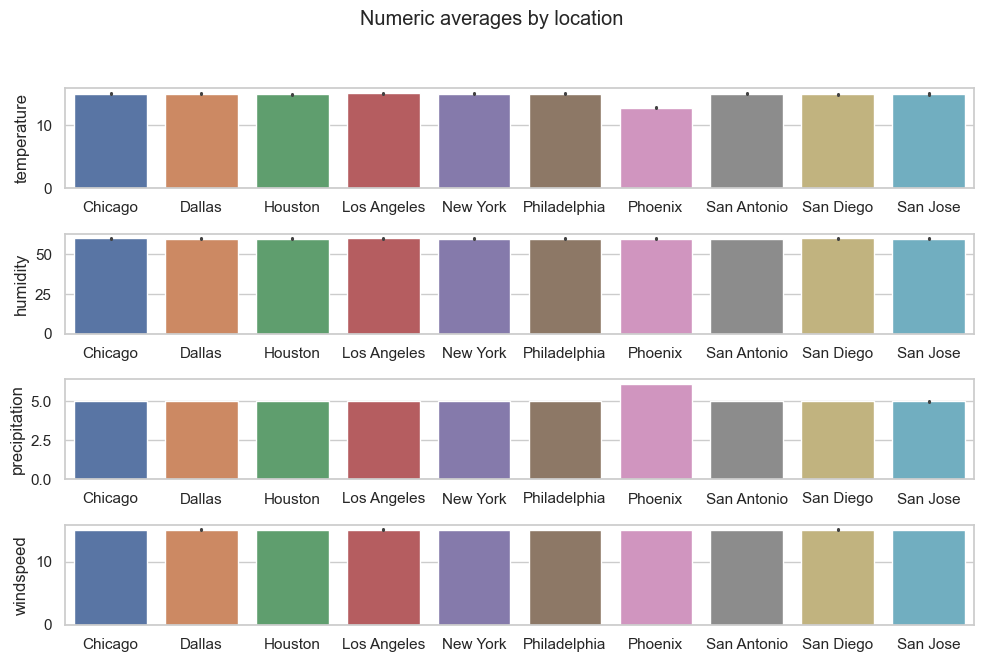

In [40]:
# Visualization of averages
fig, axes = plt.subplots(nrows=len(weather_vars))
target_dir = join(images_dir, 'averages')
la = zip(weather_vars, axes)
for l, a in la:
    sns.barplot(df, x='location', hue='location', order=location_order, hue_order=location_order, y=l, ax=a)
    a.set_xlabel('')
plt.tight_layout()
fig.suptitle('Numeric averages by location', y=1.1);
plt.savefig(join(target_dir, 'Numeric averages by location'), bbox_inches='tight')

In [41]:
# Averages by month
df['month'] = df.datetime.dt.month
df.month = df.month.astype('int')
df_avg_month = df.groupby(['location', 'month'])[weather_vars].agg('mean')
display(df_avg_month.head(10))

temperature   humidity  precipitation  windspeed
location month                                                  
Chicago  1        14.860229  59.985753       5.010381  15.009369
         2        15.121009  59.998639       4.980473  14.956879
         3        15.076371  60.204593       5.027832  15.060337
         4        15.091991  60.023860       4.974326  14.992471
         5        14.855531  60.277003       5.028435  14.937635
Dallas   1        14.931791  59.933118       5.010677  14.963746
         2        14.978184  60.091013       4.986060  15.029430
         3        14.830816  59.933271       4.960800  15.068715
         4        15.153468  59.860477       5.042010  15.060449
         5        15.239108  60.018756       4.986495  14.958791

#### Averages by month

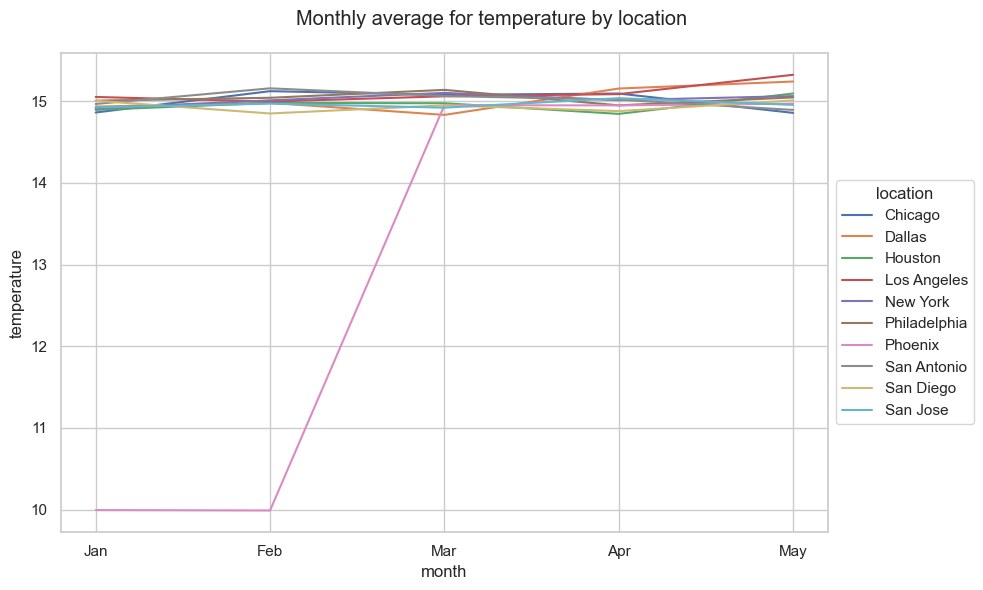

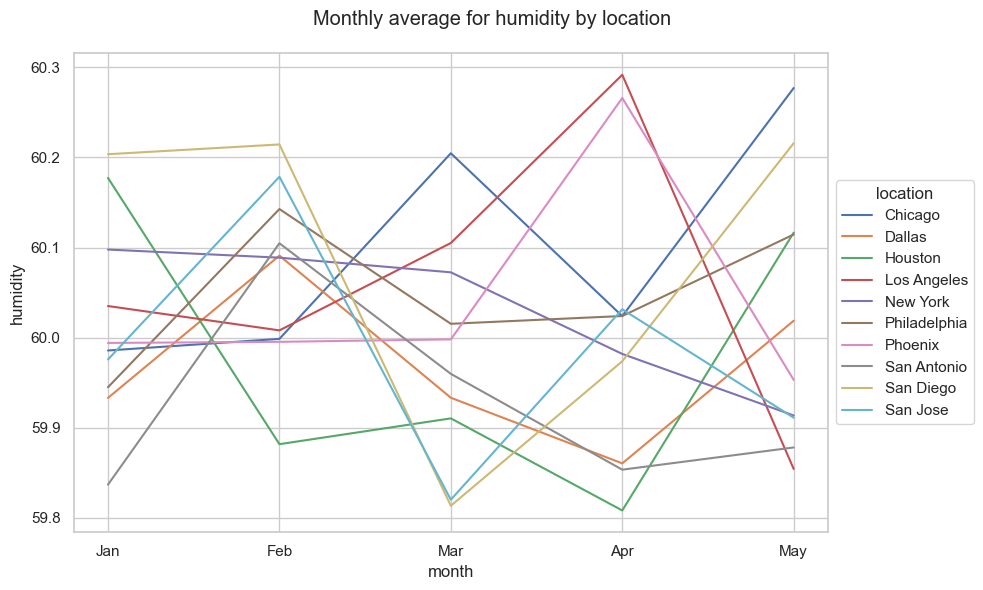

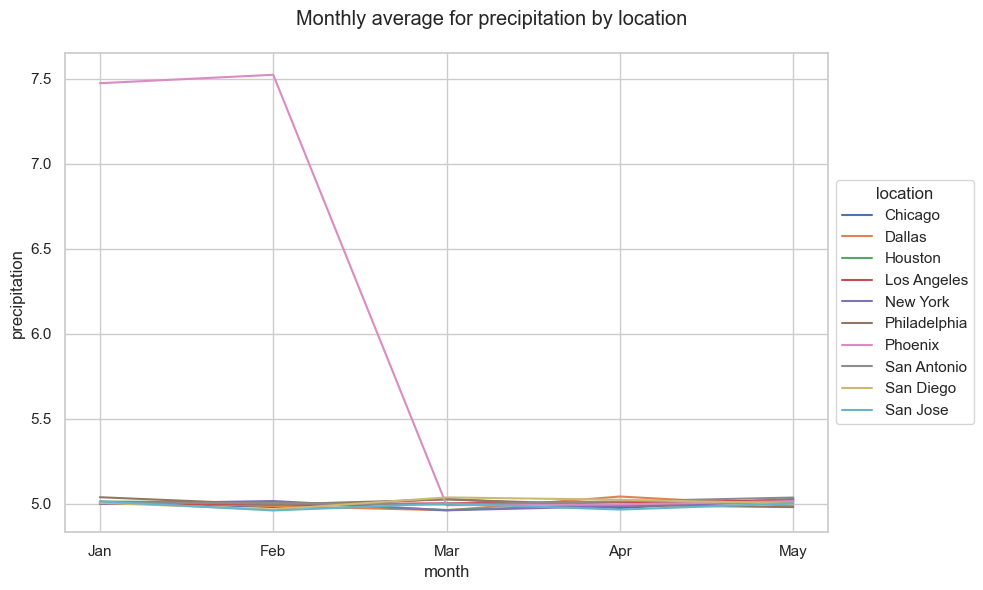

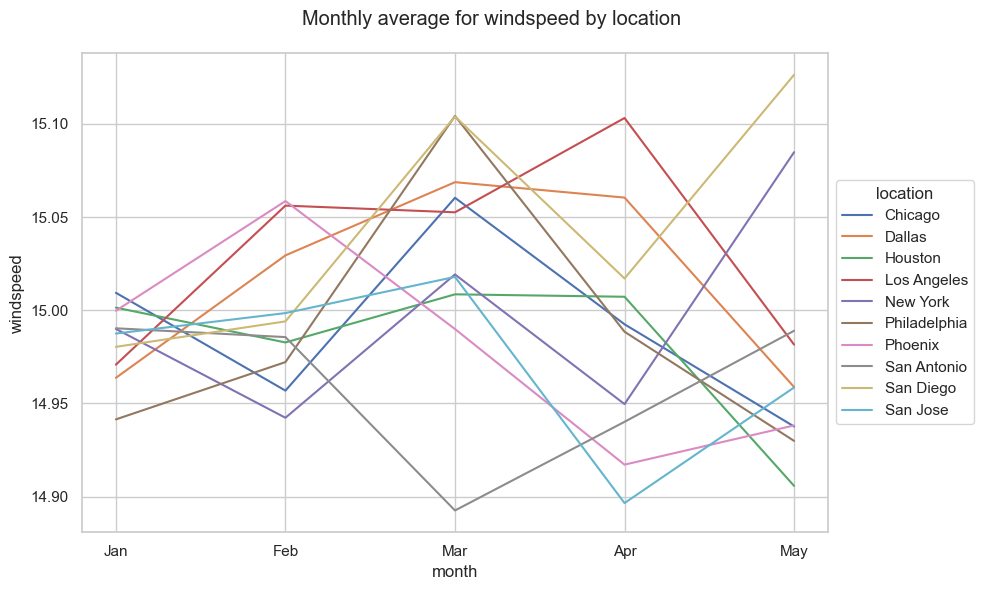

In [42]:
# Visualization of averages by month
x_labels = {
    1: 'Jan',
    2: 'Feb',
    3: 'Mar',
    4: 'Apr',
    5: 'May',
}
target_dir = join(images_dir, 'averages', 'monthly')
for c in weather_vars:
    fig, ax = plt.subplots()
    ax.set_xticks(list(x_labels.keys()))
    ax.set_xticklabels(list(x_labels.values()))
    sns.lineplot(df_avg_month, x='month', y=c, hue_order=location_order, hue='location', ax=ax)
    sns.move_legend(ax, 'upper left', bbox_to_anchor=(1, 0.75))
    title = f'Monthly average for {c} by location'
    fig.suptitle(title)
    fig.savefig(join(target_dir, f'{title}.png'), bbox_inches='tight')
    plt.tight_layout()

#### Averages by date

In [43]:
# Create 'day' column and calculate daily averages by location
df['date'] = df.datetime.dt.date
df_avg_day = df.groupby(['location', 'date'])[weather_vars].agg('mean')
print(df_avg_day.isna().sum())
df_avg_day.head(15)

temperature      0
humidity         0
precipitation    0
windspeed        0
dtype: int64


temperature   humidity  precipitation  windspeed
location date                                                        
Chicago  2024-01-01    14.591593  60.861902       5.000215  15.239925
         2024-01-02    14.096501  59.635024       5.075185  15.324471
         2024-01-03    13.929910  59.152315       5.062087  15.398121
         2024-01-04    14.850404  58.612329       5.020053  14.441218
         2024-01-05    15.040743  59.565218       4.814772  15.081683
         2024-01-06    15.473233  59.325961       5.071816  14.928236
         2024-01-07    15.133750  59.939330       4.853550  15.184684
         2024-01-08    14.399803  60.749134       5.155456  15.306266
         2024-01-09    15.704255  59.597430       4.964354  14.327000
         2024-01-10    15.422694  59.175568       4.937768  15.045432
         2024-01-11    15.577684  59.917359       4.863460  15.168154
         2024-01-12    14.026486  60.225900       4.981063  15.313962
         2024-01-13    15.264806  59.526626       5.075242  15.198912
         2024-01-14    15.393794  59.949849       4.960454  15.204033
         2024-01-15    14.944955  60.140341       4.910294  14.979374

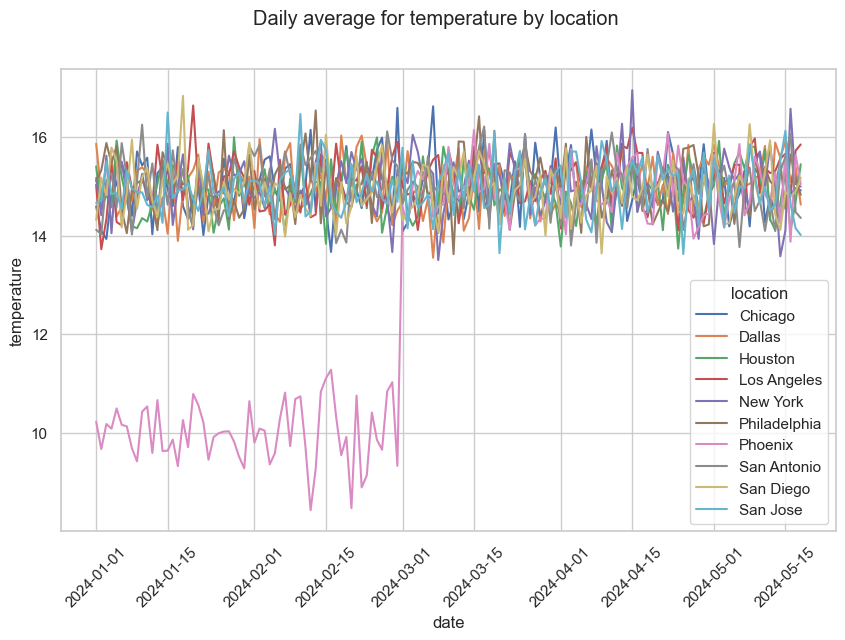

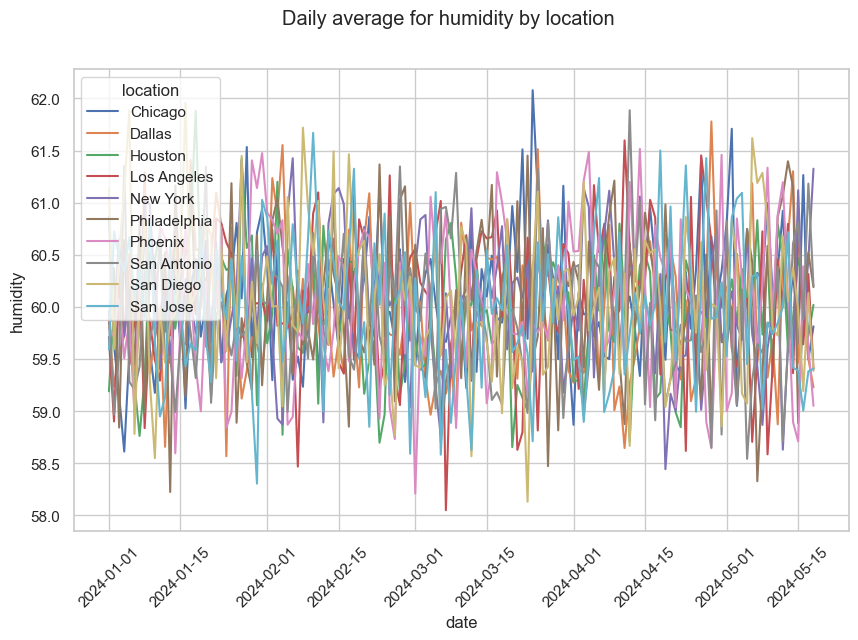

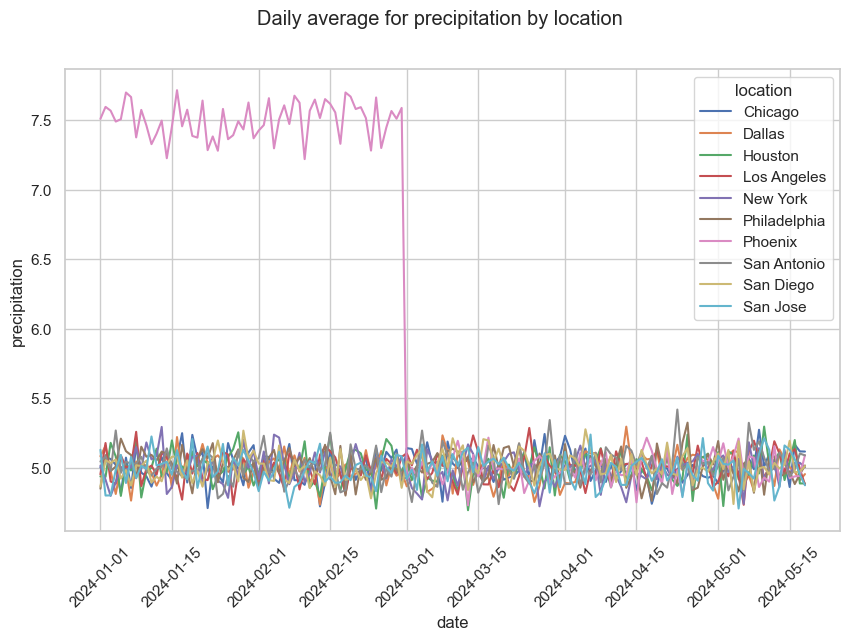

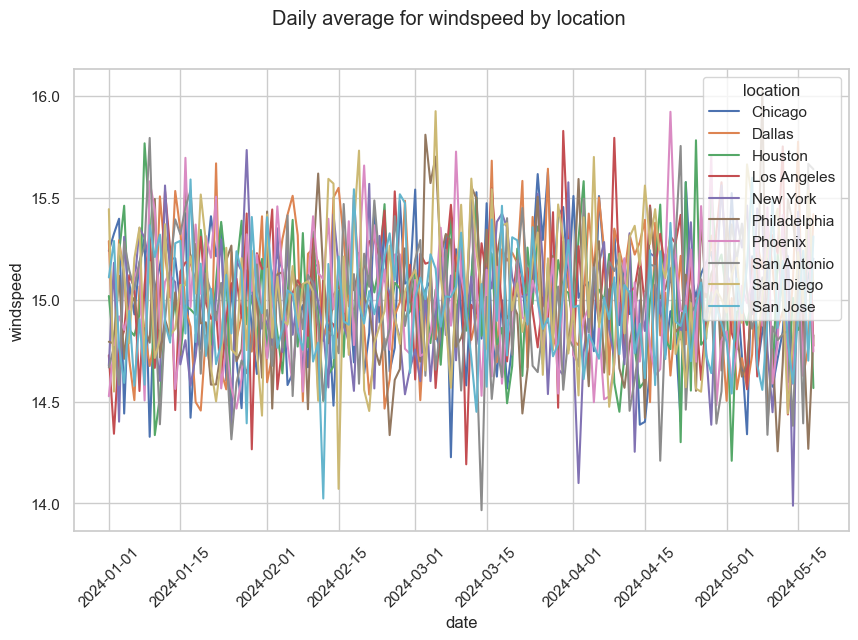

In [44]:
# Visualize time-series of daily averages by location
target_dir = join(images_dir, 'averages', 'daily')
for c in weather_vars:
    fig, ax = plt.subplots()
    sns.lineplot(df_avg_day, x='date', y=c, hue='location', hue_order=location_order, ax=ax)
    plt.xticks(rotation=45)
    title = f'Daily average for {c} by location'
    plt.suptitle(title)
    fig.savefig(join(target_dir, f'{title}.png'))
    plt.show()

#### Averages by time of day

In [45]:
# Averages by time of day
df['hour'] = df.datetime.dt.hour
bins = [0, 6, 12, 18, 24]
labels = ['night', 'morning', 'afternoon', 'evening']
df['time_of_day'] = pd.cut(df.hour, bins=bins, labels=labels, right=False)
df.time_of_day = df.time_of_day.astype('category')
df.head()

,location,datetime,temperature,humidity,precipitation,windspeed,month,date,hour,time_of_day
0,San Diego,2024-01-14 21:12:46,10.683001,41.195754,4.020119,8.233540,1,2024-01-14,21,evening
1,San Diego,2024-05-17 15:22:10,8.734140,58.319107,9.111623,27.715161,5,2024-05-17,15,afternoon
2,San Diego,2024-05-11 09:30:59,11.632436,38.820175,4.607511,28.732951,5,2024-05-11,9,morning
3,Philadelphia,2024-02-26 17:32:39,-8.628976,54.074474,3.183720,26.367303,2,2024-02-26,17,afternoon
4,San Antonio,2024-04-29 13:23:51,39.808213,72.899908,9.598282,29.898622,4,2024-04-29,13,afternoon


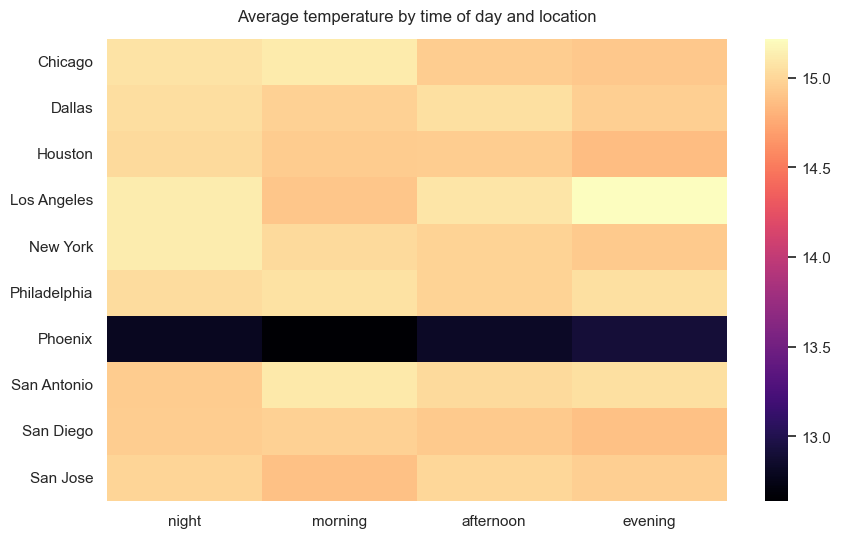

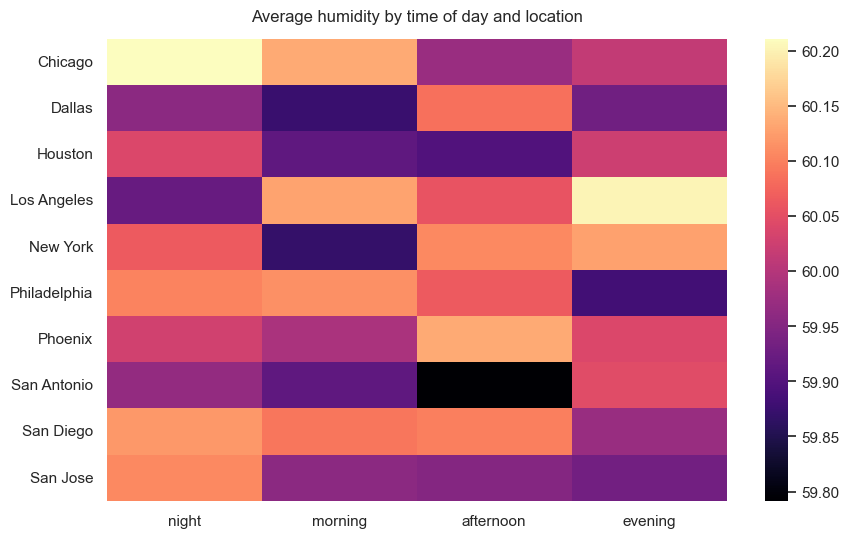

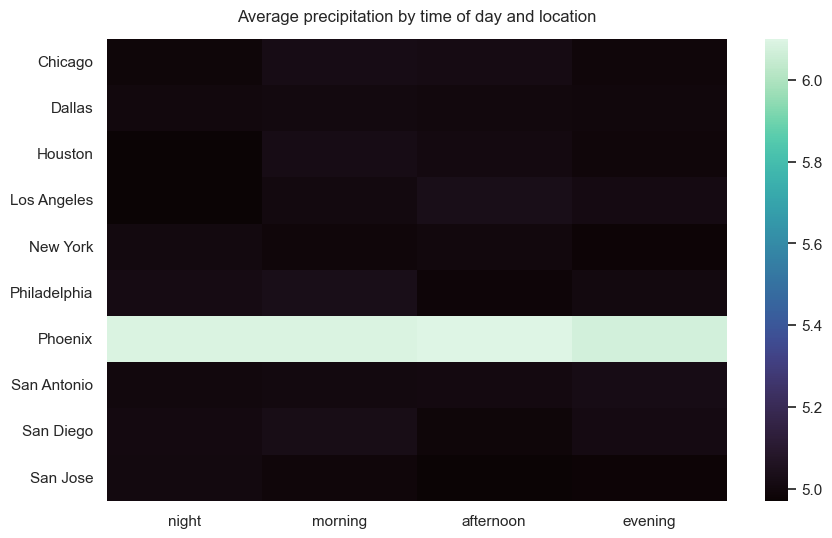

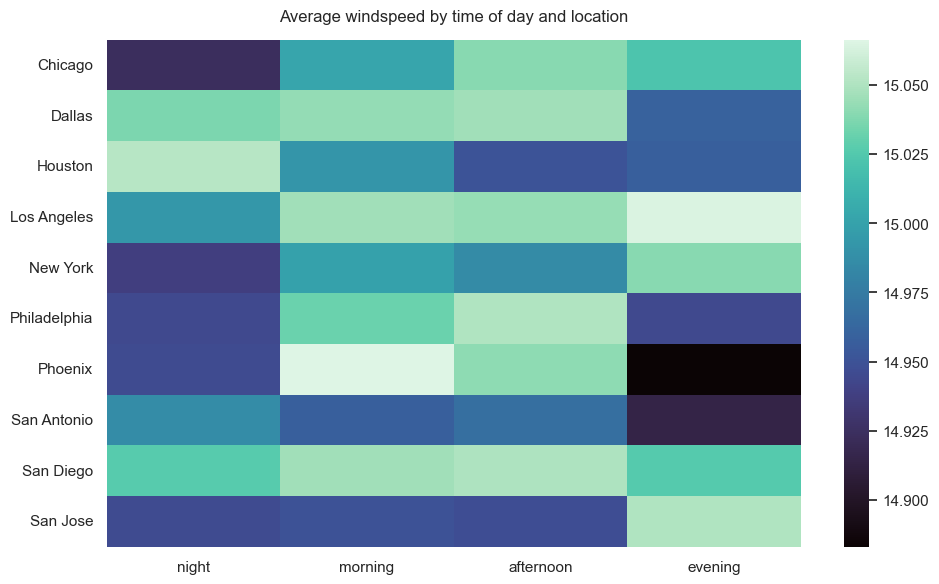

In [46]:
# Visualization of averages by time of day
df_agg = df.groupby(['location', 'time_of_day'], observed=False)[weather_vars].agg('mean').reset_index()
target_dir = join(images_dir, 'averages', 'time of day')
for c in weather_vars:
    fig, ax = plt.subplots()
    df_agg_piv = df_agg.pivot(index='location', columns='time_of_day')[c]
    sns.heatmap(df_agg_piv, cmap='mako' if c in ['precipitation', 'windspeed'] else 'magma', ax=ax)
    ax.set_xlabel('')
    ax.set_ylabel('')
    title = f'Average {c} by time of day and location'
    ax.set_title(title, y=1.02)
    fig.savefig(join(target_dir, f'{title}.png'))
plt.tight_layout()


#### Rolling averages

In [47]:
# Caulculate rolling averages by location

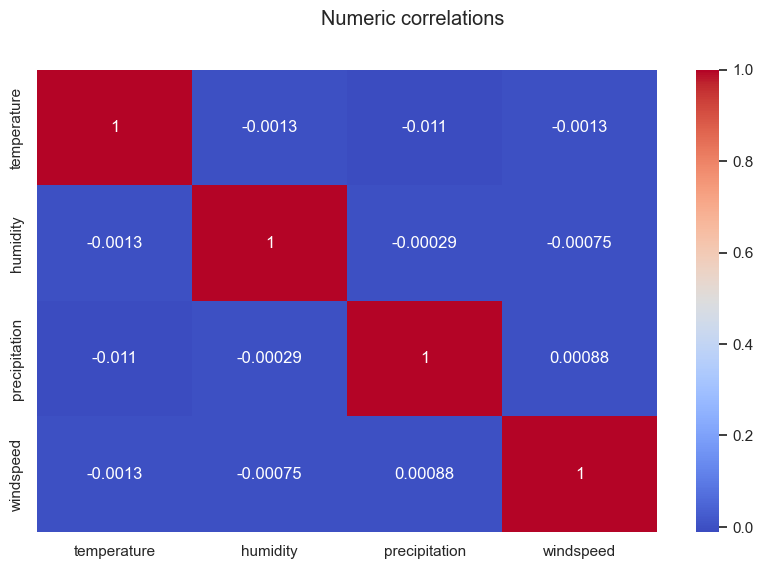

In [48]:
# Visualize numeric correlations
fig, ax = plt.subplots()
sns.heatmap(df[weather_vars].corr(numeric_only=True,), annot=True, cmap='coolwarm', ax=ax)
fig.suptitle('Numeric correlations')
fig.savefig(join(images_dir, 'Numeric correlations.png'))
plt.show()

### Summary from EDA

The time-series for monthly averages reveal little that is noteworthy per location. Overall, though, they show that the data for Phoenix's temperature and precipitation is atypical compared to other locations for the first two months. The time-series for daily averages reinforces this.

The heatmaps for averages based on time of day highlight some maximums and minimums but the averages cluster so tightly around specific values that there is, again, little of interest here, save that the variables for these locations are very consistent through winter and spring, excepting Phoenix for temperature and precipitation (seen [here](#averages-by-location-and-month) and [here](#averages-by-location-and-time-of-day)).

The correlation matrix does not reveal any strong correlations between the numeric variables.

## 5. Deeper analysis or modeling
- Trend analysis, segment analysis, KPIs
- Simple models if needed
- Explain business implications of findings

### Analyzing Phoenix's temperature and precipitation data

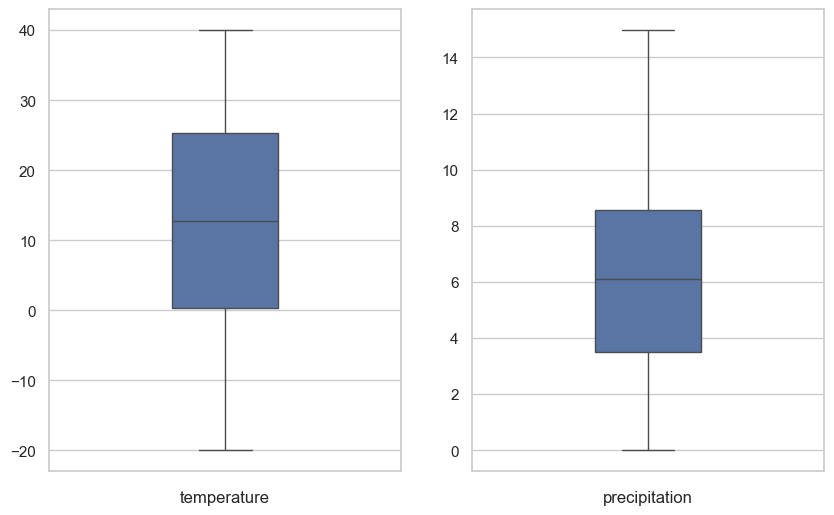

In [49]:
# Visualize Phoenix's data using boxplots
pho_anom_vars = ['temperature', 'precipitation']  # anomalous Phoenix variables
fig, axes = plt.subplots(ncols=len(pho_anom_vars))
df_pho_anom = df[df.location == 'Phoenix'][pho_anom_vars]
la = zip(pho_anom_vars, axes)
for l, a in la:
    sns.boxplot(df_pho_anom, y=l, ax=a, width=0.3)
    a.set_xlabel(l)
    a.set_ylabel('')
plt.show()

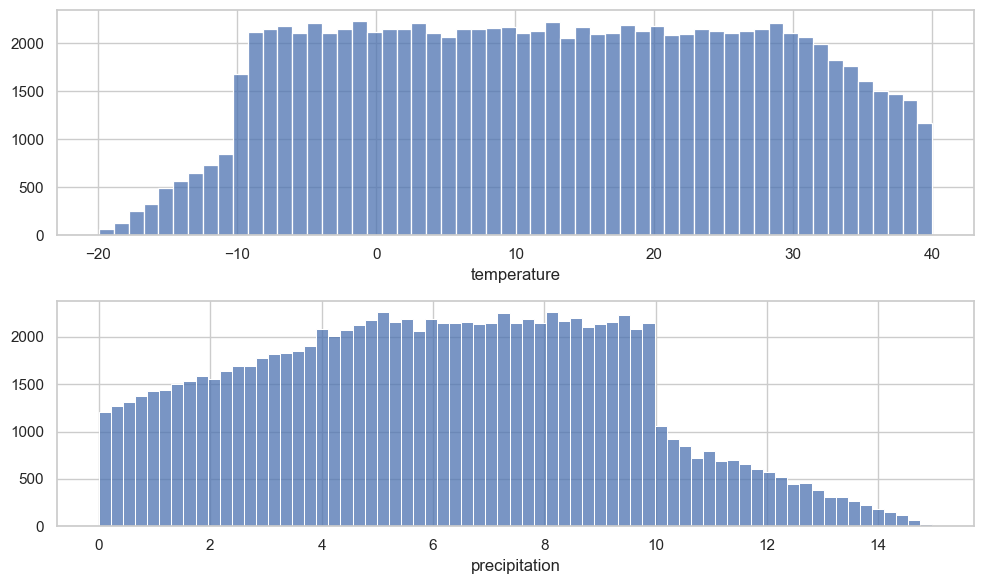

In [50]:
# Visualize Phoenix's data using histograms
fig, axes = plt.subplots(nrows=len(pho_anom_vars))
la = zip(pho_anom_vars, axes)
for l, a in la:
    sns.histplot(df_pho_anom, x=l, ax=a)
    a.set_xlabel(l)
    a.set_ylabel('')
plt.tight_layout()
plt.show()

In [51]:
# View Phoenix's counts for temperature and  precipitation relative to other locations

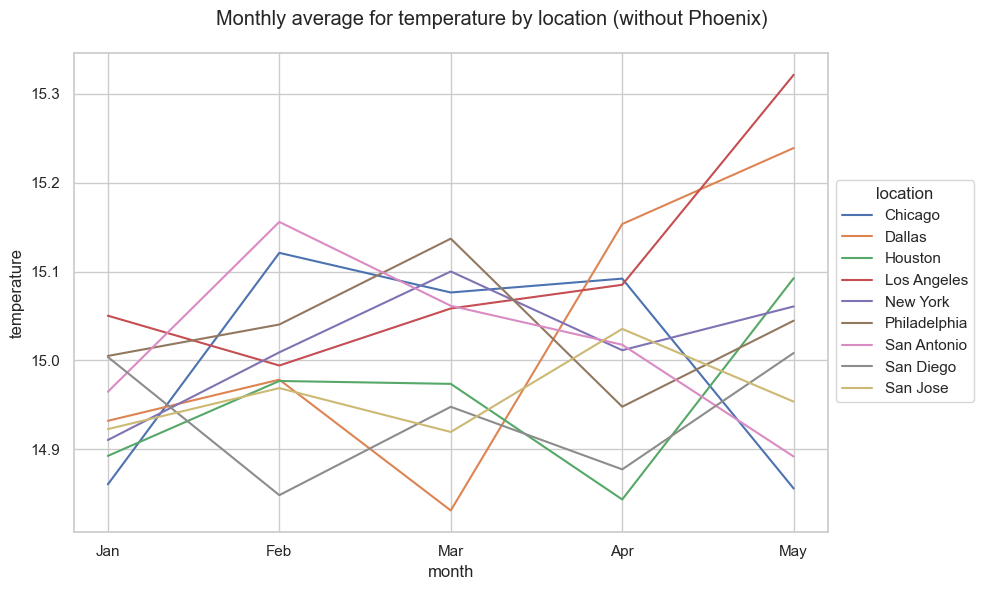

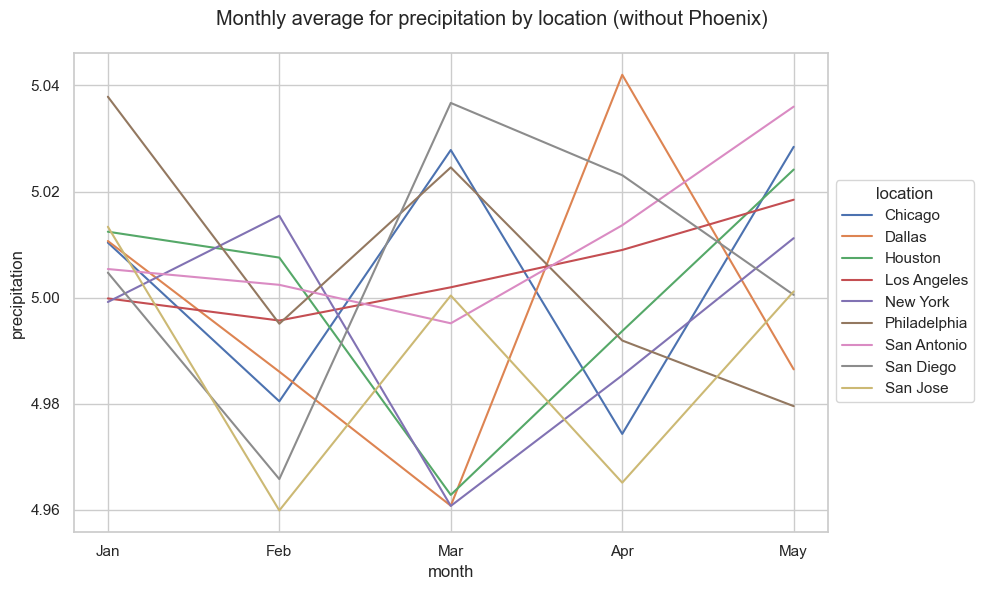

In [52]:
# Visualization of temperature and precipitations averages by month without Phoenix
loc_ord_wo_pho = [x for x in location_order if x != 'Phoenix']
target_dir = join(images_dir, 'averages', 'monthly')
for c in pho_anom_vars:
    fig, ax = plt.subplots()
    ax.set_xticks(list(x_labels.keys()))
    ax.set_xticklabels(list(x_labels.values()))
    sns.lineplot(df_avg_month, x='month', y=c, hue_order=loc_ord_wo_pho, hue='location', ax=ax)
    sns.move_legend(ax, 'upper left', bbox_to_anchor=(1, 0.75))
    title = f'Monthly average for {c} by location (without Phoenix)'
    fig.suptitle(title)
    fig.savefig(join(target_dir, f'{title}.png'), bbox_inches='tight')
    plt.tight_layout()

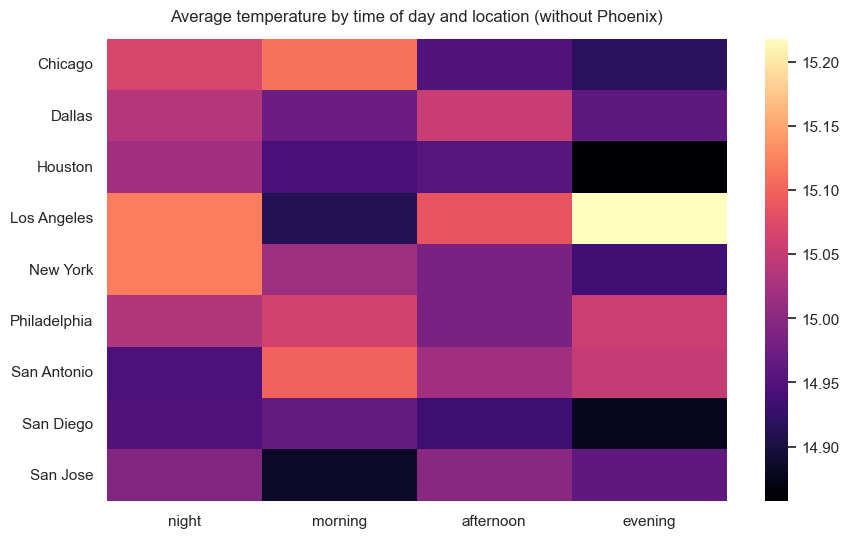

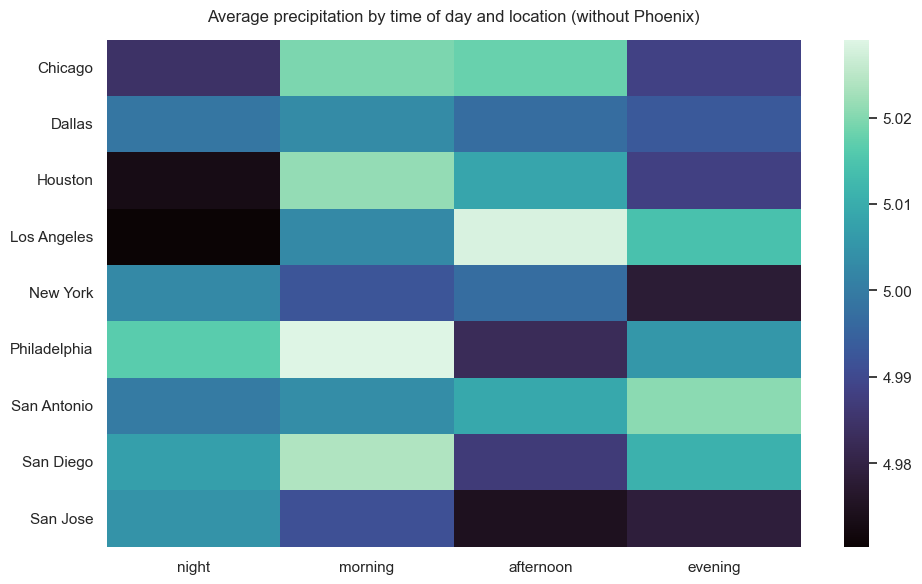

In [53]:
# Visualization of averages by time of day with Phoenix removed
target_dir = join(images_dir, 'averages', 'time of day')
for c in pho_anom_vars:
    fig, ax = plt.subplots()
    df_agg_piv = df_agg[df_agg.location != 'Phoenix'].pivot(index='location', columns='time_of_day')[c]
    sns.heatmap(df_agg_piv, cmap='mako' if c in ['precipitation', 'windspeed'] else 'magma', ax=ax)
    ax.set_xlabel('')
    ax.set_ylabel('')
    title = f'Average {c} by time of day and location (without Phoenix)'
    ax.set_title(title, y=1.02)
    fig.savefig(join(target_dir, f'{title}.png'))
plt.tight_layout()

## 6. Insights and recommendations

### Insights

- Though Phoenix's data is atypical relative to the other locations, there are no outliers as indicated by the boxplots. Calculating a Z-score and seeing how far certain values are from the mean makes little sense, since the distribution is not a normal one. Therefore, there are no values that it would make sense to impute or remove.
  - Additionally, I do not know specifically how this synthetic data was produced, so I can only guess at what caused that difference. It is possible that the person producing the data intentionally introduced those anomalies in. It is also possible that they made a mistake when setting values for synthesizing this data. If I knew more about their process, I might be able to determine how to handle those values. As this is manufactured data, I will assume these values were intended.
- Since data trends are consistent and unremarkable from city to city and over time, briefly treating Phoenix as an anomaly and visualizing the dataset without it helps with standard visual analysis.
- When comparing locations in this dataset to their (assumed) real-world counterparts, it is noteworthy that these locations have roughly similar values for each location (e.g. San Diego, CA and Chicago, Il have similar temperatures and precipitation levels during winter).

### Recommendations

- Determine what decisions were made when synthesizing this data that would produce the phenomena that is seen with Phoenix's temperature and precipiation variables.

## 7. Conclusion
- Recap of goals and findings
- Limitations
- Suggestions for future work

## 8. Appendix
- Additional charts
- Definitions
- Notes on calculations